In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "../data/processed"

TARGET_COL = "NLDC_DEMAND"

LOOKBACK = 96
HORIZON = 48
WINDOW = LOOKBACK + HORIZON

SEASON = 96

BATCH_SIZE = 64
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 5

print("LOOKBACK:", LOOKBACK)
print("HORIZON:", HORIZON)
print("WINDOW:", WINDOW)

LOOKBACK: 96
HORIZON: 48
WINDOW: 144


In [3]:
train_df = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv"),
    parse_dates=["timestamp"]
)

val_df = pd.read_csv(
    os.path.join(DATA_DIR, "validation.csv"),
    parse_dates=["timestamp"]
)

test_df = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv"),
    parse_dates=["timestamp"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (14400, 33)
Validation shape: (2976, 33)
Test shape: (5856, 33)


In [4]:
print("Columns:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nFirst 5 rows:")
display(train_df.head())

Columns:
['timestamp', 'NLDC_DEMAND', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'delhi_T2M', 'delhi_RH2M', 'delhi_SOLAR', 'delhi_WS10M', 'delhi_PRECIP', 'mumbai_T2M', 'mumbai_RH2M', 'mumbai_SOLAR', 'mumbai_WS10M', 'mumbai_PRECIP', 'bengaluru_T2M', 'bengaluru_RH2M', 'bengaluru_SOLAR', 'bengaluru_WS10M', 'bengaluru_PRECIP', 'kolkata_T2M', 'kolkata_RH2M', 'kolkata_SOLAR', 'kolkata_WS10M', 'kolkata_PRECIP', 'guwahati_T2M', 'guwahati_RH2M', 'guwahati_SOLAR', 'guwahati_WS10M', 'guwahati_PRECIP']

Data types:
timestamp           datetime64[ns]
NLDC_DEMAND                float64
hour                         int64
minute                       int64
day_of_week                  int64
day_of_month                 int64
month                        int64
is_weekend                   int64
delhi_T2M                  float64
delhi_RH2M                 float64
delhi_SOLAR                float64
delhi_WS10M                float64
delhi_PRECIP               float64
mumbai_

,timestamp,NLDC_DEMAND,hour,minute,day_of_week,day_of_month,month,is_weekend,delhi_T2M,delhi_RH2M,...,kolkata_T2M,kolkata_RH2M,kolkata_SOLAR,kolkata_WS10M,kolkata_PRECIP,guwahati_T2M,guwahati_RH2M,guwahati_SOLAR,guwahati_WS10M,guwahati_PRECIP
0,2022-01-01 00:00:00,124549.903646,0,0,5,1,1,1,8.20,57.37,...,14.86,95.25,0.0,2.69,0.0,10.86,100.0,0.0,1.46,0.0
1,2022-01-01 00:15:00,124068.562500,0,15,5,1,1,1,8.20,57.37,...,14.86,95.25,0.0,2.69,0.0,10.86,100.0,0.0,1.46,0.0
2,2022-01-01 00:30:00,123853.145833,0,30,5,1,1,1,8.20,57.37,...,14.86,95.25,0.0,2.69,0.0,10.86,100.0,0.0,1.46,0.0
3,2022-01-01 00:45:00,123448.419271,0,45,5,1,1,1,8.20,57.37,...,14.86,95.25,0.0,2.69,0.0,10.86,100.0,0.0,1.46,0.0
4,2022-01-01 01:00:00,122563.572917,1,0,5,1,1,1,7.55,59.50,...,14.35,95.94,0.0,2.68,0.0,10.64,100.0,0.0,1.42,0.0


In [5]:
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print("-" * 40)
    
    print("Start:", df["timestamp"].min())
    print("End:", df["timestamp"].max())
    print("Sorted:", df["timestamp"].is_monotonic_increasing)
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
    print("Missing values:", df.isna().sum().sum())


Train
----------------------------------------
Start: 2022-01-01 00:00:00
End: 2022-06-30 23:45:00
Sorted: True
Duplicate timestamps: 0
Missing values: 0

Validation
----------------------------------------
Start: 2022-07-01 00:00:00
End: 2022-07-31 23:45:00
Sorted: True
Duplicate timestamps: 0
Missing values: 0

Test
----------------------------------------
Start: 2022-08-01 00:00:00
End: 2022-09-30 23:45:00
Sorted: True
Duplicate timestamps: 0
Missing values: 0


In [6]:
for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    expected_hour = df["timestamp"].dt.hour
    expected_minute = df["timestamp"].dt.minute
    expected_dow = df["timestamp"].dt.dayofweek

    print(f"\n{name}")
    print("-" * 40)
    print("Hour mismatches:",
          (df["hour"] != expected_hour).sum())
    print("Minute mismatches:",
          (df["minute"] != expected_minute).sum())
    print("Day-of-week mismatches:",
          (df["day_of_week"] != expected_dow).sum())


Train
----------------------------------------
Hour mismatches: 0
Minute mismatches: 0
Day-of-week mismatches: 0

Validation
----------------------------------------
Hour mismatches: 0
Minute mismatches: 0
Day-of-week mismatches: 0

Test
----------------------------------------
Hour mismatches: 0
Minute mismatches: 0
Day-of-week mismatches: 0


In [7]:
def add_time_features(df):
    df = df.copy()

    minutes_of_day = df["hour"] * 60 + df["minute"]

    df["time_of_day_sin"] = np.sin(
        2 * np.pi * minutes_of_day / 1440
    )

    df["time_of_day_cos"] = np.cos(
        2 * np.pi * minutes_of_day / 1440
    )

    df["dow_sin"] = np.sin(
        2 * np.pi * df["day_of_week"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi * df["day_of_week"] / 7
    )

    return df


train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)

print("New train shape:", train_df.shape)
print(
    train_df[
        ["timestamp", "hour", "minute", "day_of_week",
         "time_of_day_sin", "time_of_day_cos",
         "dow_sin", "dow_cos"]
    ].head()
)


New train shape: (14400, 37)
            timestamp  hour  minute  day_of_week  time_of_day_sin  \
0 2022-01-01 00:00:00     0       0            5         0.000000   
1 2022-01-01 00:15:00     0      15            5         0.065403   
2 2022-01-01 00:30:00     0      30            5         0.130526   
3 2022-01-01 00:45:00     0      45            5         0.195090   
4 2022-01-01 01:00:00     1       0            5         0.258819   

   time_of_day_cos   dow_sin   dow_cos  
0         1.000000 -0.974928 -0.222521  
1         0.997859 -0.974928 -0.222521  
2         0.991445 -0.974928 -0.222521  
3         0.980785 -0.974928 -0.222521  
4         0.965926 -0.974928 -0.222521  


In [21]:
FEATURE_COLS = [
    "NLDC_DEMAND",
    "time_of_day_sin",
    "time_of_day_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "day_of_month",
    "month",

    "delhi_T2M",
    "delhi_RH2M",
    "delhi_SOLAR",
    "delhi_WS10M",
    "delhi_PRECIP",

    "mumbai_T2M",
    "mumbai_RH2M",
    "mumbai_SOLAR",
    "mumbai_WS10M",
    "mumbai_PRECIP",

    "bengaluru_T2M",
    "bengaluru_RH2M",
    "bengaluru_SOLAR",
    "bengaluru_WS10M",
    "bengaluru_PRECIP",

    "kolkata_T2M",
    "kolkata_RH2M",
    "kolkata_SOLAR",
    "kolkata_WS10M",
    "kolkata_PRECIP",

    "guwahati_T2M",
    "guwahati_RH2M",
    "guwahati_SOLAR",
    "guwahati_WS10M",
    "guwahati_PRECIP",
]

print("Number of features:", len(FEATURE_COLS))

Number of features: 33


In [22]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(train_df[FEATURE_COLS])
target_scaler.fit(train_df[[TARGET_COL]])

print("Feature scaler fitted on:", len(FEATURE_COLS), "features")
print("Target scaler fitted on:", TARGET_COL)

Feature scaler fitted on: 33 features
Target scaler fitted on: NLDC_DEMAND


In [23]:
train_scaled = feature_scaler.transform(
    train_df[FEATURE_COLS]
)

val_scaled = feature_scaler.transform(
    val_df[FEATURE_COLS]
)

test_scaled = feature_scaler.transform(
    test_df[FEATURE_COLS]
)

train_target_scaled = target_scaler.transform(
    train_df[[TARGET_COL]]
).ravel()

val_target_scaled = target_scaler.transform(
    val_df[[TARGET_COL]]
).ravel()

test_target_scaled = target_scaler.transform(
    test_df[[TARGET_COL]]
).ravel()

print("Train features:", train_scaled.shape)
print("Validation features:", val_scaled.shape)
print("Test features:", test_scaled.shape)

print("\nTrain target:", train_target_scaled.shape)
print("Validation target:", val_target_scaled.shape)
print("Test target:", test_target_scaled.shape)

Train features: (14400, 33)
Validation features: (2976, 33)
Test features: (5856, 33)

Train target: (14400,)
Validation target: (2976,)
Test target: (5856,)


In [24]:
def create_sequences(features, target, timestamps, lookback, horizon):
    X = []
    y = []
    y_timestamps = []

    timestamps = pd.Series(
        pd.to_datetime(timestamps)
    ).reset_index(drop=True)

    for start in range(
        len(features) - lookback - horizon + 1
    ):
        input_end = start + lookback
        output_end = input_end + horizon

        input_times = timestamps.iloc[start:input_end]
        output_times = timestamps.iloc[input_end:output_end]

        all_times = pd.concat(
            [input_times, output_times],
            ignore_index=True
        )

        time_diffs = all_times.diff().dropna()

        # Skip windows that cross a timestamp gap
        if not (
            time_diffs == pd.Timedelta(minutes=15)
        ).all():
            continue

        X.append(features[start:input_end])
        y.append(target[input_end:output_end])
        y_timestamps.append(output_times.to_numpy())

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(y_timestamps)
    )


X_train, y_train, train_y_times = create_sequences(
    train_scaled,
    train_target_scaled,
    train_df["timestamp"],
    LOOKBACK,
    HORIZON
)

X_val, y_val, val_y_times = create_sequences(
    val_scaled,
    val_target_scaled,
    val_df["timestamp"],
    LOOKBACK,
    HORIZON
)

X_test, y_test, test_y_times = create_sequences(
    test_scaled,
    test_target_scaled,
    test_df["timestamp"],
    LOOKBACK,
    HORIZON
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (14114, 96, 33)
y_train: (14114, 48)
X_val: (2833, 96, 33)
y_val: (2833, 48)
X_test: (5713, 96, 33)
y_test: (5713, 48)


In [25]:
print("Input shape:", X_train[0].shape)
print("Output shape:", y_train[0].shape)

print("\nInput period:")
print(train_df["timestamp"].iloc[0])
print(train_df["timestamp"].iloc[95])

print("\nForecast period:")
print(train_y_times[0][0])
print(train_y_times[0][-1])

print("\nFirst timestep feature values:")
print(X_train[0, 0])

Input shape: (96, 33)
Output shape: (48,)

Input period:
2022-01-01 00:00:00
2022-01-01 23:45:00

Forecast period:
2022-01-02T00:00:00.000000000
2022-01-02T11:45:00.000000000

First timestep feature values:
[0.42727888 0.5        1.         0.         0.35689586 1.
 0.         0.         0.11271878 0.5494134  0.         0.19766206
 0.         0.29848078 0.80813384 0.         0.3808438  0.
 0.24301155 0.97203726 0.         0.44241118 0.02849003 0.20795964
 0.941271   0.         0.30023095 0.         0.1556096  1.
 0.         0.20583941 0.        ]


In [13]:
sample_idx = 0

print("Input shape:", X_train[sample_idx].shape)
print("Output shape:", y_train[sample_idx].shape)

print("\nInput period:")
print(
    train_df["timestamp"].iloc[sample_idx:
                               sample_idx + LOOKBACK].iloc[[0, -1]]
)

print("\nForecast period:")
print(
    train_df["timestamp"].iloc[
        sample_idx + LOOKBACK:
        sample_idx + LOOKBACK + HORIZON
    ].iloc[[0, -1]]
)

print("\nFirst input timestep:")
print(X_train[sample_idx, 0])

print("\nFirst 5 future demand values (scaled):")
print(y_train[sample_idx, :5])

Input shape: (96, 31)
Output shape: (48,)

Input period:
0    2022-01-01 00:00:00
95   2022-01-01 23:45:00
Name: timestamp, dtype: datetime64[ns]

Forecast period:
96    2022-01-02 00:00:00
143   2022-01-02 11:45:00
Name: timestamp, dtype: datetime64[ns]

First input timestep:
[0.42727888 1.         0.11271878 0.5494134  0.         0.19766206
 0.         0.29848078 0.80813384 0.         0.3808438  0.
 0.24301155 0.97203726 0.         0.44241118 0.02849003 0.20795964
 0.941271   0.         0.30023095 0.         0.1556096  1.
 0.         0.20583941 0.         0.5        1.         0.
 0.35689586]

First 5 future demand values (scaled):
[0.40921244 0.40624517 0.4031896  0.39629453 0.39170188]


In [26]:
inputs = Input(
    shape=(LOOKBACK, len(FEATURE_COLS))
)

x = LSTM(
    128,
    return_sequences=True
)(inputs)
x = Dropout(0.2)(x)

x = LSTM(
    64,
    return_sequences=True
)(x)
x = Dropout(0.2)(x)

x = LSTM(
    32
)(x)
x = Dropout(0.2)(x)

x = Dense(
    32,
    activation="relu"
)(x)

outputs = Dense(
    HORIZON,
    activation="linear",
    name="forecast_output"
)(x)

lstm_model = Model(
    inputs=inputs,
    outputs=outputs
)

lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 33)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 96, 128)             │          82,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 96, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 96, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 96, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ forecast_output (Dense)              │ (None, 48)                  │           1,584 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 147,408 (575.81 KB)

 Trainable params: 147,408 (575.81 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Loss: MSE")
print("Metric: MAE")
print("Early stopping patience:", EARLY_STOP_PATIENCE)

Optimizer: Adam
Learning rate: 0.001
Loss: MSE
Metric: MAE
Early stopping patience: 5


In [28]:
start_time = time.time()

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Epochs completed: {len(history.history['loss'])}")

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 84s 331ms/step - loss: 0.0496 - mae: 0.1559 - val_loss: 0.0242 - val_mae: 0.1213
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 68s 309ms/step - loss: 0.0161 - mae: 0.0988 - val_loss: 0.0187 - val_mae: 0.0973
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 72s 324ms/step - loss: 0.0127 - mae: 0.0858 - val_loss: 0.0214 - val_mae: 0.1082
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 71s 321ms/step - loss: 0.0120 - mae: 0.0823 - val_loss: 0.0218 - val_mae: 0.1112
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 68s 309ms/step - loss: 0.0099 - mae: 0.0732 - val_loss: 0.0153 - val_mae: 0.0811
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 71s 321ms/step - loss: 0.0082 - mae: 0.0658 - val_loss: 0.0159 - val_mae: 0.0810
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 65s 294ms/step - loss: 0.0082 - mae: 0.0654 - val_loss: 0.0113 - val_mae: 0.0585
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 69s 312ms/step - loss: 0.0072 - mae: 0.0612 - val_loss: 0.0106 - val_mae: 0.0558
Epoch 9/50
221/221 ━━━━━━━━━━━━━

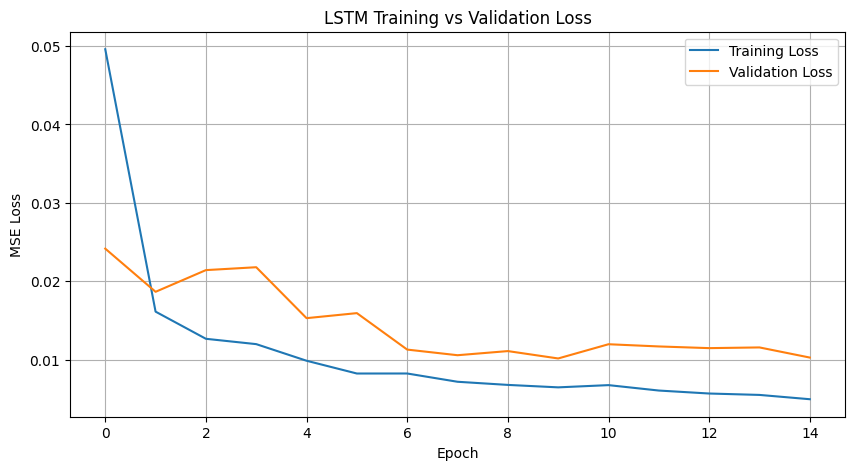

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [31]:
y_pred_scaled = lstm_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("Predictions shape:", y_pred_scaled.shape)
print("Actual shape:", y_test.shape)

90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step
Predictions shape: (5713, 48)
Actual shape: (5713, 48)


In [32]:
y_pred = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).reshape(y_pred_scaled.shape)

y_actual = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

print("Predictions shape:", y_pred.shape)
print("Actual shape:", y_actual.shape)

print("\nFirst 5 predicted values:")
print(y_pred[0, :5])

print("\nFirst 5 actual values:")
print(y_actual[0, :5])

Predictions shape: (5713, 48)
Actual shape: (5713, 48)

First 5 predicted values:
[175078.48 176027.45 172987.31 172381.58 171748.5 ]

First 5 actual values:
[174808.84 173641.75 172103.75 171033.36 169444.33]


In [33]:
actual_flat = y_actual.ravel()
pred_flat = y_pred.ravel()

# MAE
mae = np.mean(
    np.abs(actual_flat - pred_flat)
)

# RMSE
rmse = np.sqrt(
    np.mean((actual_flat - pred_flat) ** 2)
)

# MAPE
mape = np.mean(
    np.abs(
        (actual_flat - pred_flat) / actual_flat
    )
) * 100

# R²
ss_res = np.sum(
    (actual_flat - pred_flat) ** 2
)

ss_tot = np.sum(
    (actual_flat - np.mean(actual_flat)) ** 2
)

r2 = 1 - (ss_res / ss_tot)

# MASE
train_target = train_df[TARGET_COL].to_numpy()

naive_scale = np.mean(
    np.abs(
        train_target[SEASON:] -
        train_target[:-SEASON]
    )
)

mase = mae / naive_scale

print("LSTM TEST RESULTS")
print("=" * 40)

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.4f}%")
print(f"R²:   {r2:.4f}")
print(f"MASE: {mase:.4f}")

print(
    f"Seasonal-naive scale: "
    f"{naive_scale:,.2f}"
)

LSTM TEST RESULTS
MAE:  7,903.75
RMSE: 9,791.50
MAPE: 4.5814%
R²:   0.1608
MASE: 1.7821
Seasonal-naive scale: 4,435.11


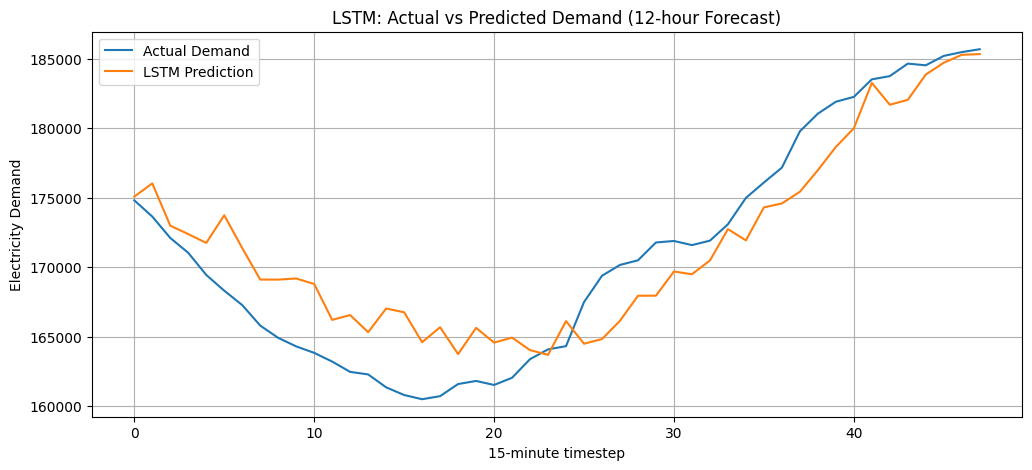

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_actual[0],
    label="Actual Demand"
)

plt.plot(
    y_pred[0],
    label="LSTM Prediction"
)

plt.xlabel("15-minute timestep")
plt.ylabel("Electricity Demand")
plt.title("LSTM: Actual vs Predicted Demand (12-hour Forecast)")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
import os
import json
import joblib

MODEL_DIR = "../models/lstm"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save trained model
lstm_model.save(
    os.path.join(MODEL_DIR, "lstm_model.keras")
)

# Save scalers
joblib.dump(
    feature_scaler,
    os.path.join(MODEL_DIR, "feature_scaler.pkl")
)

joblib.dump(
    target_scaler,
    os.path.join(MODEL_DIR, "target_scaler.pkl")
)

# Save feature list
with open(
    os.path.join(MODEL_DIR, "feature_columns.json"),
    "w"
) as f:
    json.dump(FEATURE_COLS, f, indent=2)

print("LSTM artifacts saved to:", MODEL_DIR)

LSTM artifacts saved to: ../models/lstm


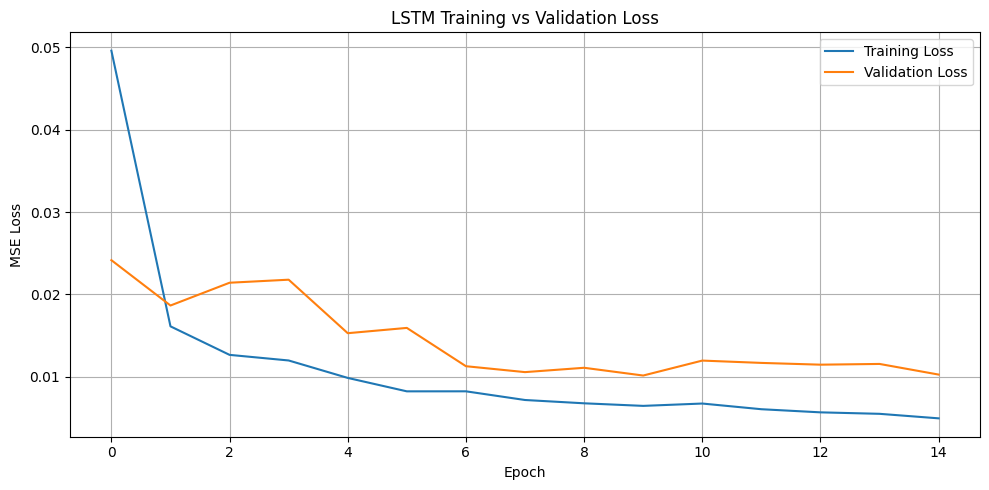

Training history saved.


In [36]:
# Save training history
history_path = os.path.join(
    MODEL_DIR,
    "training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        {
            key: [float(v) for v in values]
            for key, values in history.history.items()
        },
        f,
        indent=2
    )

# Save training/validation loss plot
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        MODEL_DIR,
        "training_history.png"
    ),
    dpi=150
)

plt.show()

print("Training history saved.")

In [37]:
# Save test predictions
predictions_df = pd.DataFrame({
    "forecast_start": test_y_times[:, 0],
    "actual_mean": y_actual.mean(axis=1),
    "predicted_mean": y_pred.mean(axis=1)
})

predictions_path = os.path.join(
    MODEL_DIR,
    "test_predictions_summary.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False
)

# Save complete metrics
metrics = {
    "model": "LSTM",
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "num_features": len(FEATURE_COLS),
    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE": float(mape),
    "R2": float(r2),
    "MASE": float(mase),
    "seasonal_naive_scale": float(naive_scale),
    "epochs_completed": len(history.history["loss"]),
    "training_time_seconds": float(training_time)
}

metrics_path = os.path.join(
    MODEL_DIR,
    "metrics.json"
)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Test prediction summary saved to:", predictions_path)
print("Metrics saved to:", metrics_path)

Test prediction summary saved to: ../models/lstm\test_predictions_summary.csv
Metrics saved to: ../models/lstm\metrics.json


In [38]:
# Create full prediction table
full_predictions = pd.DataFrame({
    "forecast_start": test_y_times[:, 0]
})

for i in range(HORIZON):
    full_predictions[f"actual_t+{i+1}"] = y_actual[:, i]
    full_predictions[f"predicted_t+{i+1}"] = y_pred[:, i]

full_predictions_path = os.path.join(
    MODEL_DIR,
    "test_predictions_full.csv"
)

full_predictions.to_csv(
    full_predictions_path,
    index=False
)

# Save final model configuration
config = {
    "model": "LSTM",
    "target": TARGET_COL,
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "sampling_interval": "15 minutes",
    "num_features": len(FEATURE_COLS),
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOP_PATIENCE,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "loss": "MSE",
    "metrics": ["MAE"],
    "season": SEASON,
    "seed": SEED
}

config_path = os.path.join(
    MODEL_DIR,
    "config.json"
)

with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("Full predictions saved to:", full_predictions_path)
print("Configuration saved to:", config_path)

print("\nLSTM ARTIFACTS")
print("=" * 40)

for filename in sorted(os.listdir(MODEL_DIR)):
    print(filename)

Full predictions saved to: ../models/lstm\test_predictions_full.csv
Configuration saved to: ../models/lstm\config.json

LSTM ARTIFACTS
config.json
feature_columns.json
feature_scaler.pkl
lstm_model.keras
metrics.json
requirements.txt
target_scaler.pkl
test_predictions_full.csv
test_predictions_summary.csv
training_history.json
training_history.png
